In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

%matplotlib inline
sns.set(style='whitegrid')

current_dir = os.getcwd()
base_dir = os.path.dirname(current_dir)
train_path = os.path.join(base_dir, 'data', 'preprocessed', 'train_data.csv')
test_path = os.path.join(base_dir, 'data', 'preprocessed', 'test_data.csv')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
print(f"Dữ liệu huấn luyện: {train_df.shape}")
print(f"Dữ liệu kiểm tra: {test_df.shape}\n")

Dữ liệu huấn luyện: (7292, 14)
Dữ liệu kiểm tra: (1824, 14)



# 1. Feature engineering
* **Tạo cột tên đường:** 
* **Target Encoding (Median):** Chuyển đổi các biến định danh (Quận, Tên đường) thành đơn giá trung vị ($Gia/m^2$). Sử dụng **Median** thay vì Mean để tránh bị lệch bởi các căn nhà "ngáo giá".
* **Log Transformation:** Áp dụng hàm Log cho Diện tích và Giá để thu nhỏ khoảng biến thiên, giúp phân phối dữ liệu gần với phân phối chuẩn hơn.
* **Interaction Feature:** Tạo biến tương tác `tuong_tac_vitri_dientich` (Diện tích x Vị trí) để mô hình hiểu rằng cùng một diện tích nhưng ở vị trí đắc địa sẽ có giá trị cộng thêm cao hơn.
* **Binning:** Chia diện tích thành 4 nhóm (Quartiles) để mô hình xử lý tốt hơn các phân khúc nhà khác nhau.

In [2]:
import pandas as pd
import re

def extract_street_name(address):
    if not isinstance(address, str) or address.strip() == "":
        return "Unknown"
    
    # 1. Chuẩn hóa: xóa khoảng trắng thừa
    address = address.strip()
    
    # 2. ƯU TIÊN 1: Tìm sau chữ "Đường" hoặc "Phố"
    # Regex này lấy cụm chữ sau 'Đường/Phố' cho đến dấu phẩy tiếp theo
    street_match = re.search(r'(?:Đường|Phố)\s+([^,]+)', address, re.IGNORECASE)
    if street_match:
        street = street_match.group(1).strip()
        # Loại bỏ các tiền tố số nhà nếu lỡ bị dính (vd: "123 Xuân Thủy" -> "Xuân Thủy")
        street = re.sub(r'^\d+\s*[a-zA-Z]?\s*', '', street)
        return street.title()

    # 3. ƯU TIÊN 2: Tìm cụm đứng trước "Phường", "Xã", "Huyện"
    # Tách địa chỉ thành các phần bởi dấu phẩy
    parts = [p.strip() for p in address.split(',')]
    
    for i in range(len(parts) - 1):
        current_part = parts[i]
        next_part = parts[i+1].lower()
        
        # Nếu phần tiếp theo chứa từ khóa hành chính
        if any(word in next_part for word in ['phường', 'xã', 'quận', 'huyện', 'tp.', 'thành phố']):
            # Kiểm tra phần hiện tại không phải là số nhà thuần túy hoặc chứa từ khóa hành chính
            if not any(word in current_part.lower() for word in ['phường', 'xã', 'quận', 'huyện', 'số']):
                # Loại bỏ số nhà/ngõ ngách ở đầu (vd: "Ngõ 10 Yên Sở" -> "Yên Sở")
                clean_street = re.sub(r'^(?:Số|Ngõ|Ngách|Hẻm)\s*\d+.*?\s+', '', current_part, flags=re.IGNORECASE)
                # Loại bỏ số ở đầu chuỗi
                clean_street = re.sub(r'^\d+\s*[a-zA-Z]?\s*', '', clean_street)
                
                if len(clean_street) > 2: # Tránh lấy các ký tự rác
                    return clean_street.title()
                
    return "Unknown"

# --- ÁP DỤNG CHO TRAIN VÀ TEST ---

# Tạo cột mới 'ten_duong'
train_df['ten_duong'] = train_df['dia_chi'].apply(extract_street_name)
test_df['ten_duong'] = test_df['dia_chi'].apply(extract_street_name)

# --- XỬ LÝ HẬU TRÍCH XUẤT ---
# Nếu một tên đường xuất hiện quá ít (ví dụ < 5 lần), 
# nên gộp thành "Other_Street" để tránh làm mô hình bị loãng (Overfitting)
street_counts = train_df['ten_duong'].value_counts()
rare_streets = street_counts[street_counts < 5].index

train_df['ten_duong'] = train_df['ten_duong'].replace(rare_streets, 'Other_Street')
# Với Test, những đường không có trong Train cũng nên để là Other_Street
train_unique_streets = set(train_df['ten_duong'].unique())
test_df['ten_duong'] = test_df['ten_duong'].apply(lambda x: x if x in train_unique_streets else 'Other_Street')

train_df['ten_duong'] = train_df['ten_duong'].replace(r'^\s*$', 'Unknown', regex=True)
test_df['ten_duong'] = test_df['ten_duong'].replace(r'^\s*$', 'Unknown', regex=True)
# Kiểm tra thử kết quả
print("Top 10 đường phổ biến trong Train:")
print(train_df['ten_duong'].value_counts().head(10))

Top 10 đường phổ biến trong Train:
ten_duong
Other_Street           1492
Unknown                 624
Lạc Long Quân           116
Huỳnh Tấn Phát          104
Cách Mạng Tháng Tám      96
Lê Văn Sỹ                85
Phạm Thế Hiển            69
Đoàn Văn Bơ              60
Hậu Giang                60
Quang Trung              57
Name: count, dtype: int64


In [3]:
# 1. Đếm tổng số tên đường độc nhất trên cả Train và Test
total_unique_train = train_df['ten_duong'].nunique()
total_unique_test = test_df['ten_duong'].nunique()

# 2. Hợp nhất cả 2 để xem tổng số "từ điển" tên đường Linh đang có
all_streets = pd.concat([train_df['ten_duong'], test_df['ten_duong']])
total_all = all_streets.nunique()

print(f"Số lượng tên đường trong Train: {total_unique_train}")
print(f"Số lượng tên đường trong Test:  {total_unique_test}")
print(f"--- Tổng số tên đường không trùng lặp: {total_all} ---")

print("\nTop 15 con đường xuất hiện nhiều nhất:")
print(all_streets.value_counts().head(15))

# 3. Kiểm tra xem có bao nhiêu đường "Unknown" (không trích xuất được)
unknown_count = (all_streets == "Unknown").sum()
print(f"\nSố lượng địa chỉ không trích xuất được (Unknown): {unknown_count}")

Số lượng tên đường trong Train: 368
Số lượng tên đường trong Test:  297
--- Tổng số tên đường không trùng lặp: 368 ---

Top 15 con đường xuất hiện nhiều nhất:
ten_duong
Other_Street           1928
Unknown                 808
Lạc Long Quân           140
Huỳnh Tấn Phát          134
Cách Mạng Tháng Tám     115
Lê Văn Sỹ               102
Hậu Giang                81
Phạm Thế Hiển            81
Đoàn Văn Bơ              76
Quang Trung              72
An Dương Vương           62
Dương Bá Trạc            60
Hương Lộ 2               60
Nguyễn Trãi              60
Thích Quảng Đức          59
Name: count, dtype: int64

Số lượng địa chỉ không trích xuất được (Unknown): 808


# 1. Tiền xử lý và Thiết kế đặc trưng (Feature Engineering)

Trong giai đoạn này, chúng ta tập trung vào việc trích xuất các tín hiệu giá trị từ dữ liệu văn bản và số học:
* **One-Hot Encoding (High-Frequency Streets):** Chỉ mã hóa các con đường có trên 50 tin đăng để đảm bảo mô hình không bị nhiễu bởi các khu vực quá ít dữ liệu.
* **Biến Urgent (Cần bán gấp):** Trích xuất từ mô tả để nhận diện các bất động sản có mức giá "hời" do chủ nhà đang cần thanh khoản nhanh.
* **Biến Mặt tiền (Facade):** Phân loại nhà mặt tiền và nhà hẻm, một trong những yếu tố quyết định đơn giá tại Việt Nam.
* **Log Transformation:** Áp dụng cho Diện tích đất để đưa về phân phối chuẩn, giúp mô hình Tuyến tính hoạt động ổn định hơn.

In [5]:
import pandas as pd
import numpy as np

def prepare_data_linear(df, is_train=True, train_cols=None, top_streets=None):
    df_proc = df.copy()
    
    # 1. Trích xuất biến Urgent và Mặt tiền (Giả định dựa trên Keyword)
    # Linh có thể điều chỉnh keyword tùy theo tập dữ liệu thực tế nhé
    df_proc['is_urgent'] = df_proc['tieu_de'].str.contains('gấp', case=False, na=False).astype(int)
    df_proc['is_facade'] = df_proc['tieu_de'].str.contains('mặt tiền|kinh doanh', case=False, na=False).astype(int)
    
    # 2. Xử lý dữ liệu số
    num_cols = ['dien_tich_dat', 'so_tang', 'phong_ngu', 'phong_tam']
    for col in num_cols:
        df_proc[col] = pd.to_numeric(df_proc[col], errors='coerce').fillna(df_proc[col].median())
    
    df_proc['dien_tich_log'] = np.log1p(df_proc['dien_tich_dat'])
    
    # 3. Lọc tên đường (>50 tin)
    if is_train:
        street_counts = df_proc['ten_duong'].value_counts()
        top_streets = street_counts[street_counts > 50].index.tolist()
    
    # Gán các đường không nằm trong Top thành 'Other' để giảm chiều dữ liệu
    df_proc['ten_duong_clean'] = df_proc['ten_duong'].apply(lambda x: x if x in top_streets else 'Street_Other')
    
    # 4. One-Hot Encoding cho Đường, Quận, Thành phố
    categorical_features = ['ten_duong_clean', 'quan', 'thanh_pho']
    df_final = pd.get_dummies(df_proc, columns=categorical_features, drop_first=True)
    
    # Chọn các biến đầu vào cho Model
    # Không dùng 'dien_tich_dat' gốc, dùng 'dien_tich_log'
    base_features = ['dien_tich_log', 'so_tang', 'phong_ngu', 'phong_tam', 'is_urgent', 'is_facade']
    model_features = [col for col in df_final.columns if col.startswith(tuple(categorical_features)) or col in base_features]
    
    X = df_final[model_features]
    
    if is_train:
        return X, top_streets, X.columns
    else:
        # Đồng bộ hóa tập Test với tập Train
        X = X.reindex(columns=train_cols, fill_value=0)
        return X

# Thực thi chuẩn bị dữ liệu
X_train, top_streets, train_cols = prepare_data_linear(train_df, is_train=True)
X_test = prepare_data_linear(test_df, is_train=False, train_cols=train_cols, top_streets=top_streets)

y_train = np.log1p(train_df['gia'])
y_test_real = test_df['gia']

# 2. Xây dựng mô hình Linear Regression

Tại bước này, chúng ta sử dụng thuật toán **Ordinary Least Squares (OLS)**. 
Vì đã mã hóa rất nhiều tên đường và quận, số lượng đặc trưng (features) sẽ tăng lên đáng kể. 
Mô hình sẽ cố gắng tìm ra trọng số (coefficients) tối ưu cho từng con đường và từng khu vực để đưa ra dự báo chính xác nhất về giá trị bất động sản.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Huấn luyện Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Dự báo
y_pred_log = lr_model.predict(X_test)
y_pred_real = np.expm1(y_pred_log) # Chuyển ngược từ log về giá trị thực

# 3. Đánh giá chỉ số
r2 = r2_score(np.log1p(y_test_real), y_pred_log)
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f"--- KẾT QUẢ LINEAR REGRESSION (Dự báo giá thực) ---")
print(f"R2 Score (trên thang Log): {r2:.4f}")
print(f"MAE: {mae:.4f} Tỷ VNĐ")
print(f"RMSE: {rmse:.4f} Tỷ VNĐ")

--- KẾT QUẢ LINEAR REGRESSION (Dự báo giá thực) ---
R2 Score (trên thang Log): 0.7301
MAE: 2.7893 Tỷ VNĐ
RMSE: 5.3405 Tỷ VNĐ


# 3. Trực quan hóa và Nhận xét

Chúng ta sử dụng biểu đồ Scatter Plot để so sánh mức độ tương quan giữa giá thực tế và giá dự báo. 
Đồng thời, phân tích biểu đồ sai số (Residuals) để kiểm tra xem mô hình có bị lệch ở phân khúc giá nào không. 
Việc sử dụng các biến như `is_urgent` và `is_facade` kỳ vọng sẽ giúp thu hẹp khoảng cách sai lệch trong các trường hợp nhà mặt phố hoặc chủ nhà cần bán gấp.

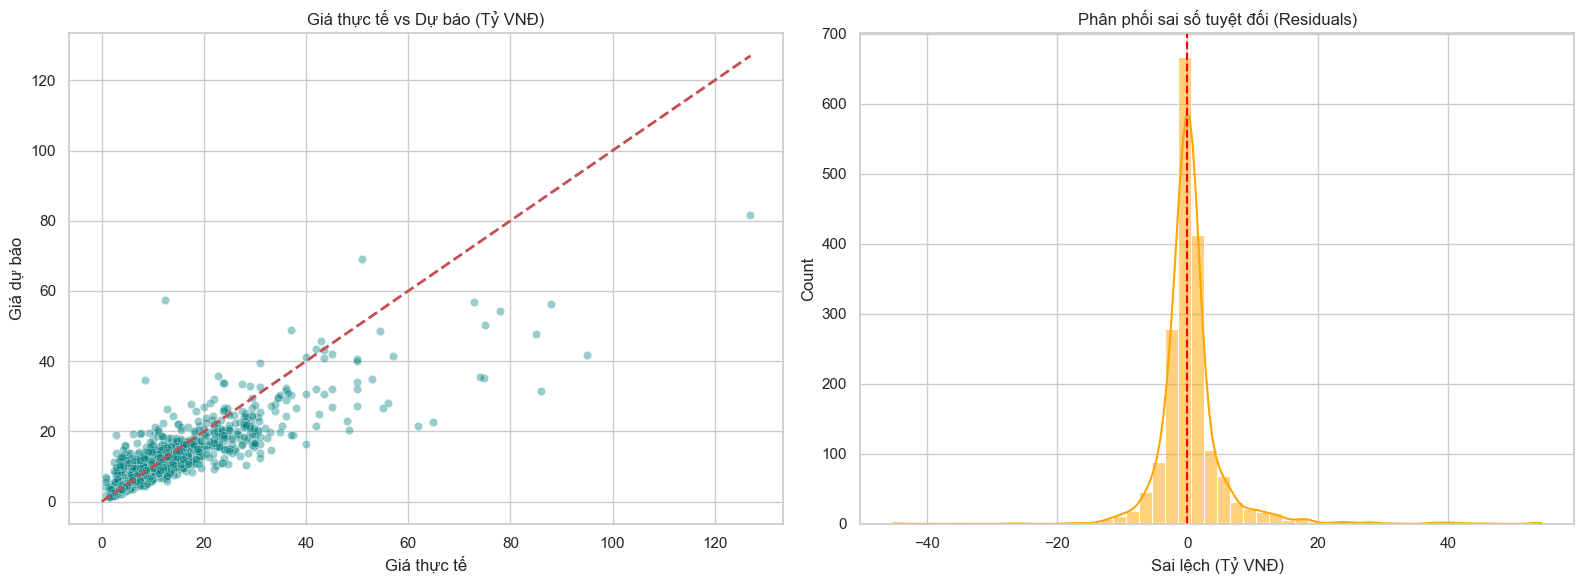


Top 5 đặc trưng ảnh hưởng mạnh nhất đến giá:
                   Feature  Coefficient
36     quan_Quận Hoàn Kiếm     0.958110
3            dien_tich_log     0.732569
33      quan_Quận Cầu Giấy     0.629099
45        quan_Quận Tây Hồ     0.627771
35  quan_Quận Hai Bà Trưng     0.481875


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))

# Biểu đồ Thực tế vs Dự báo
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_real, y=y_pred_real, alpha=0.4, color='teal')
plt.plot([0, y_test_real.max()], [0, y_test_real.max()], '--r', linewidth=2)
plt.title("Giá thực tế vs Dự báo (Tỷ VNĐ)")
plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự báo")

# Biểu đồ Phân phối sai số
plt.subplot(1, 2, 2)
residuals = y_test_real - y_pred_real
sns.histplot(residuals, bins=50, kde=True, color='orange')
plt.axvline(0, color='red', linestyle='--')
plt.title("Phân phối sai số tuyệt đối (Residuals)")
plt.xlabel("Sai lệch (Tỷ VNĐ)")

plt.tight_layout()
plt.show()

# Hiển thị 5 biến có ảnh hưởng lớn nhất (Coefficients)
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr_model.coef_})
print("\nTop 5 đặc trưng ảnh hưởng mạnh nhất đến giá:")
print(coef_df.sort_values(by='Coefficient', ascending=False).head(5))